In [1]:
!pip install kagglehub

In [2]:
import kagglehub
#Download latest version
path=kagglehub.dataset_download("shantanudhakadd/bank-customer-churn-prediction")
print("Path to dataset files:",path)

Using Colab cache for faster access to the 'bank-customer-churn-prediction' dataset.
Path to dataset files: /kaggle/input/bank-customer-churn-prediction


In [3]:
#Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
#Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve)

import warnings
warnings.filterwarnings('ignore')

In [4]:
df=pd.read_csv(os.path.join(path,"Churn_Modelling.csv"))
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# **Data Inspection**

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
df['Exited'].value_counts(normalize=True)

,proportion
Exited,
0,0.7963
1,0.2037


# **Exploratory Data Analysis (EDA)**

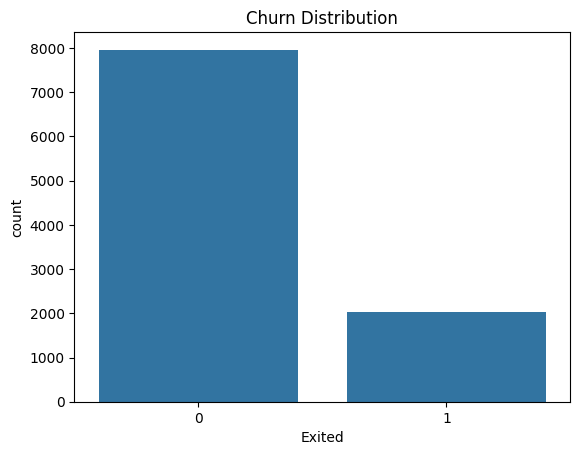

In [7]:
sns.countplot(x='Exited',data=df)
plt.title("Churn Distribution")
plt.show()

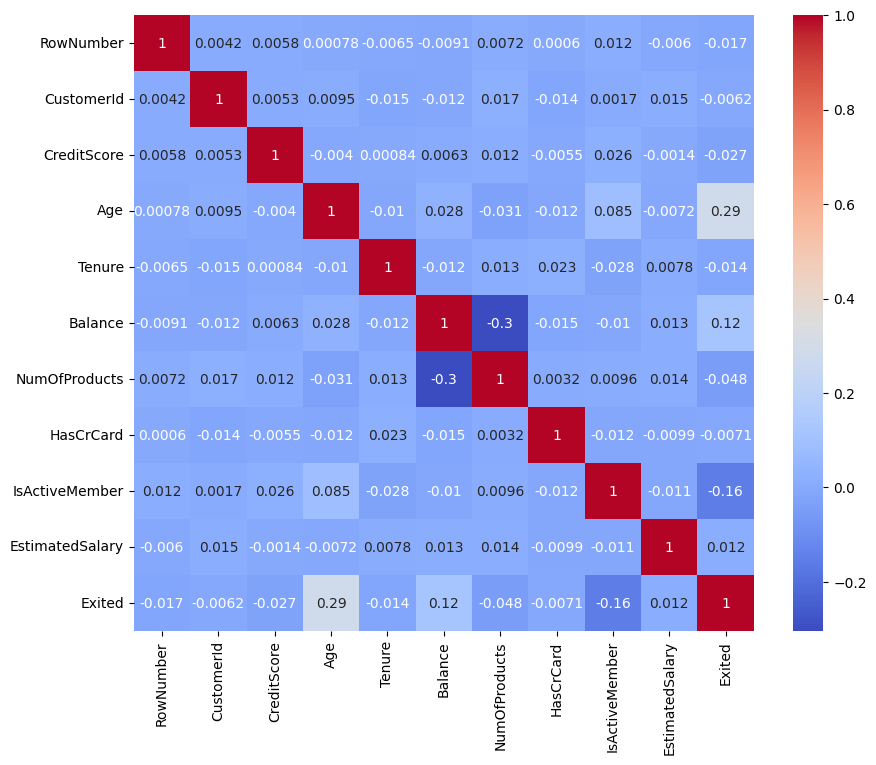

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

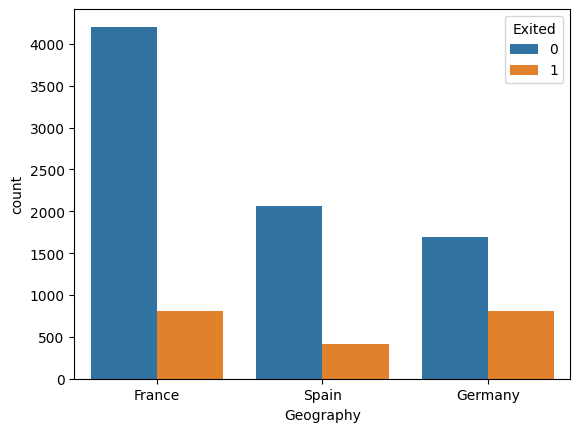

In [9]:
sns.countplot(x='Geography',hue='Exited',data=df)
plt.show()

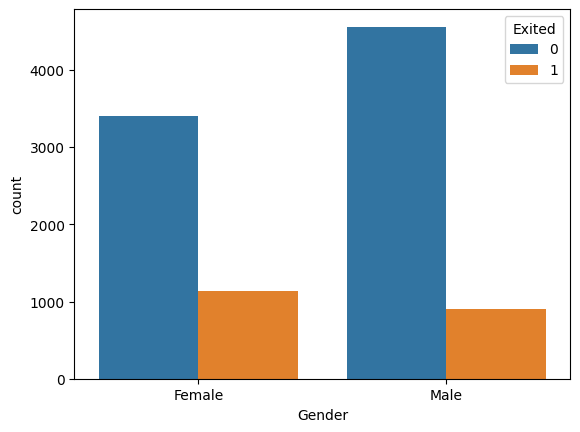

In [10]:
sns.countplot(x='Gender',hue='Exited',data=df)
plt.show()

# **Data Cleaning & Preprocessing**

In [11]:
df.drop(['RowNumber','CustomerId','Surname'],axis=1,inplace=True)

In [12]:
X=df.drop('Exited', axis=1)
y=df['Exited']

In [13]:
categorical_cols=['Geography','Gender']
numerical_cols=X.drop(columns=categorical_cols).columns

In [14]:
preprocessor=ColumnTransformer(transformers=[('num',StandardScaler(),numerical_cols),('cat',OneHotEncoder(drop='first'),categorical_cols)])

# **Train-Test Split**

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# **Model 1: Logistic Regression**

In [16]:
log_model=Pipeline(steps=[('preprocessor',preprocessor),('classifier',LogisticRegression())])
log_model.fit(X_train,y_train)
y_pred_log=log_model.predict(X_test)
y_prob_log=log_model.predict_proba(X_test)[:,1]

In [17]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_prob_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.808
ROC AUC: 0.77475626628169
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



# **Model 2: Random Forest**

In [18]:
rf_model=Pipeline(steps=[('preprocessor',preprocessor),('classifier',RandomForestClassifier(random_state=42))])
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)
y_prob_rf=rf_model.predict_proba(X_test)[:,1]
print("Accuracy:",accuracy_score(y_test,y_pred_rf))
print("ROC AUC:",roc_auc_score(y_test,y_prob_rf))
print(classification_report(y_test,y_pred_rf))

Accuracy: 0.864
ROC AUC: 0.8522181657774878
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



# **Model 3: Gradient Boosting**

In [19]:
gb_model=Pipeline(steps=[('preprocessor',preprocessor),('classifier',GradientBoostingClassifier())])
gb_model.fit(X_train,y_train)
y_pred_gb=gb_model.predict(X_test)
y_prob_gb=gb_model.predict_proba(X_test)[:,1]
print("Accuracy:", accuracy_score(y_test,y_pred_gb))
print("ROC AUC:", roc_auc_score(y_test,y_prob_gb))
print(classification_report(y_test,y_pred_gb))

Accuracy: 0.87
ROC AUC: 0.8711053117832778
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [20]:
from sklearn.model_selection import GridSearchCV

In [21]:
param_grid={'classifier__n_estimators':[100,200],'classifier__learning_rate':[0.01,0.1],'classifier__max_depth':[3,5],'classifier__subsample':[0.8,1.0]}

In [22]:
grid_search=GridSearchCV(gb_model,param_grid,cv=3,scoring='roc_auc',n_jobs=-1)
grid_search.fit(X_train,y_train)
print("Best Parameters:",grid_search.best_params_)

Best Parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 1.0}


In [23]:
best_gb_model=grid_search.best_estimator_
y_pred_tuned=best_gb_model.predict(X_test)
y_prob_tuned=best_gb_model.predict_proba(X_test)[:,1]
print("Tuned Model Accuracy:",accuracy_score(y_test,y_pred_tuned))
print("Tuned ROC AUC:",roc_auc_score(y_test,y_prob_tuned))
print(classification_report(y_test,y_pred_tuned))

Tuned Model Accuracy: 0.87
Tuned ROC AUC: 0.8711053117832778
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



# **Hyperparameter Tuning Results:**

GridSearchCV was used to optimize the Gradient Boosting model using ROC-AUC as the evaluation metric.

The best hyperparameters found were identical to the default parameters of the GradientBoostingClassifier. This indicates that the baseline model was already well-suited for the dataset, and further tuning did not significantly improve performance.

Therefore, the tuned model performs similarly to the baseline Gradient Boosting model.

# **Comparing the ROC Curves**

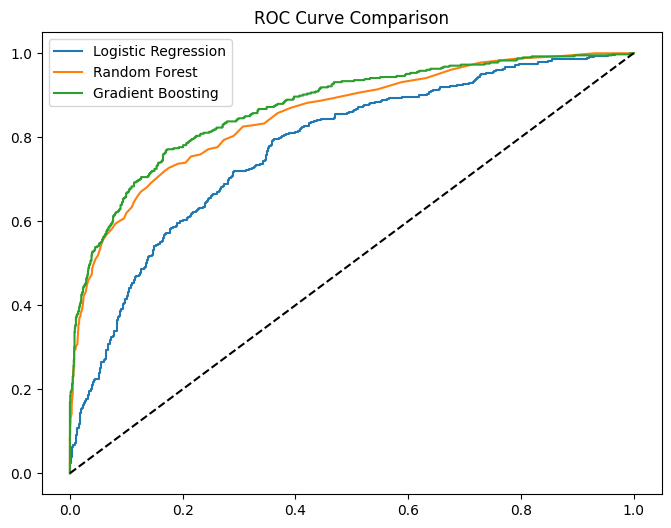

In [24]:
fpr_log,tpr_log,_=roc_curve(y_test,y_prob_log)
fpr_rf,tpr_rf,_=roc_curve(y_test,y_prob_rf)
fpr_gb,tpr_gb,_=roc_curve(y_test,y_prob_tuned)
plt.figure(figsize=(8,6))
plt.plot(fpr_log,tpr_log,label='Logistic Regression')
plt.plot(fpr_rf,tpr_rf,label='Random Forest')
plt.plot(fpr_gb,tpr_gb,label='Gradient Boosting')
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve Comparison")
plt.show()

# **Feature Importance (Random Forest Model)**

In [25]:
#Extract feature names after preprocessing
ohe=rf_model.named_steps['preprocessor'].named_transformers_['cat']
encoded_features=list(ohe.get_feature_names_out(['Geography','Gender']))
all_features=list(numerical_cols)+encoded_features
importances=rf_model.named_steps['classifier'].feature_importances_
feature_importance=pd.DataFrame({'Feature':all_features,'Importance':importances}).sort_values(by='Importance',ascending=False)
feature_importance

,Feature,Importance
1,Age,0.236485
7,EstimatedSalary,0.147016
0,CreditScore,0.142756
3,Balance,0.141756
4,NumOfProducts,0.130410
2,Tenure,0.081817
6,IsActiveMember,0.039933
8,Geography_Germany,0.028923
5,HasCrCard,0.018799
10,Gender_Male,0.018483


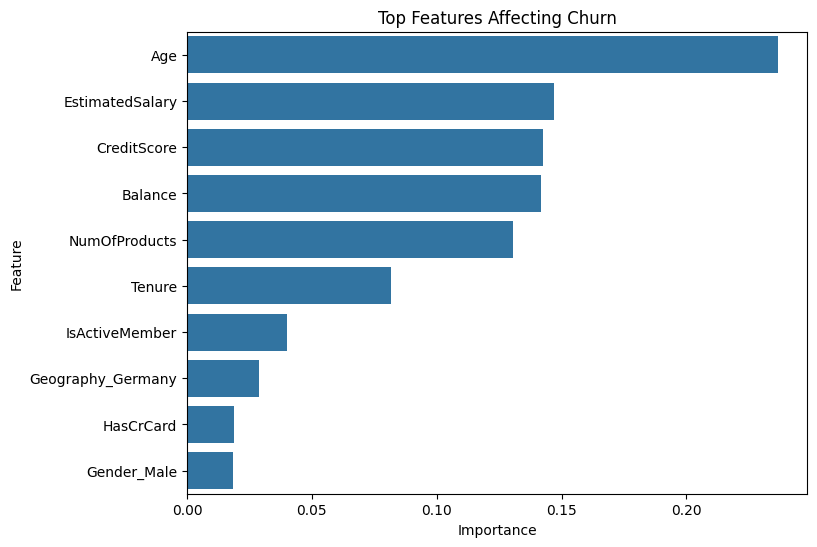

In [26]:
plt.figure(figsize=(8,6))
sns.barplot(data=feature_importance.head(10),x="Importance",y="Feature")
plt.title("Top Features Affecting Churn")
plt.show()

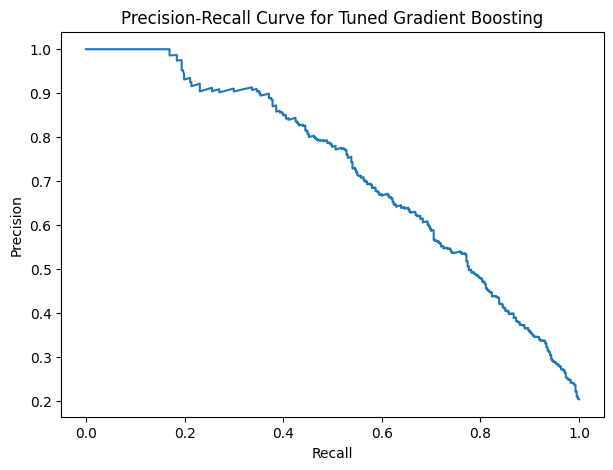

In [44]:
precision,recall,_=precision_recall_curve(y_test,y_prob_tuned)
plt.figure(figsize=(7,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Tuned Gradient Boosting")
plt.show()

# **Model Explainability using SHAP**

To better understand the model predictions, SHAP (SHapley Additive exPlanations) was used to interpret feature contributions.

SHAP helps explain:
- Which features influence churn predictions
- Whether they increase or decrease churn probability
- The magnitude of each feature's impact

In [ ]:
!pip install shap 

In [29]:
import shap
X_train_transformed=best_gb_model.named_steps['preprocessor'].transform(X_train)
feature_names=all_features

In [30]:
explainer=shap.TreeExplainer(best_gb_model.named_steps['classifier'])
shap_values=explainer.shap_values(X_train_transformed)

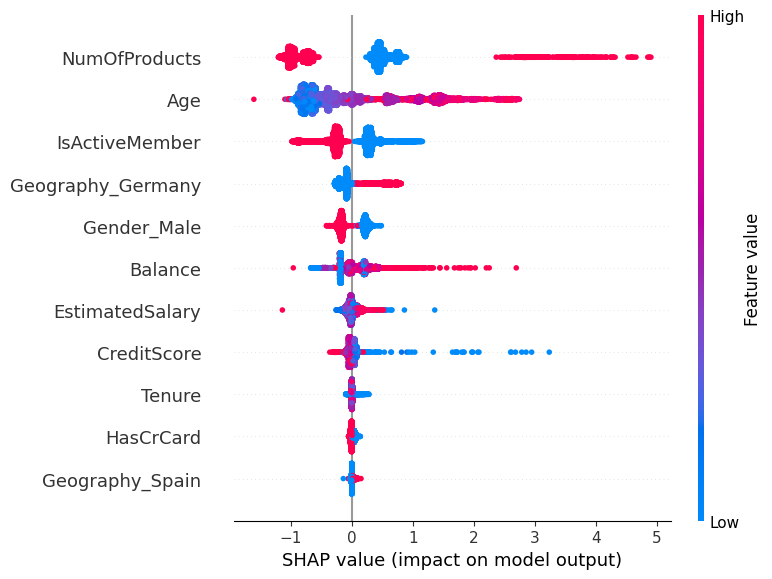

In [31]:
shap.summary_plot(shap_values,X_train_transformed,feature_names=feature_names)

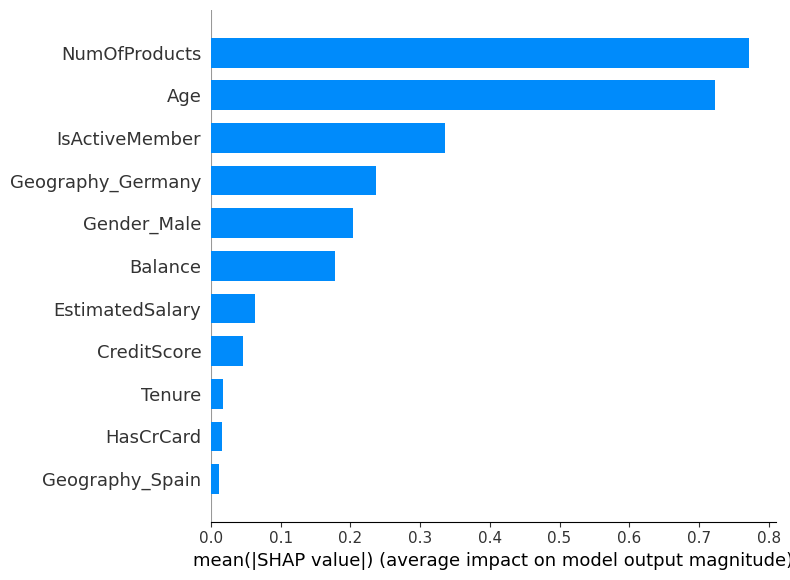

In [33]:
shap.summary_plot(shap_values,X_train_transformed,feature_names=feature_names,plot_type="bar")

# **SHAP Feature Importance vs Model Feature Importance:**

The earlier feature importance plot from the Random Forest model shows how frequently features were used for decision tree splits.

In contrast, SHAP feature importance measures the average impact of each feature on the model's predictions. SHAP provides more interpretable explanations by showing how much each feature contributes to increasing or decreasing churn probability.

Therefore, SHAP is often preferred for model interpretability in real-world machine learning applications.

# **Customer Churn Risk Segmentation**

Instead of only predicting whether a customer will churn, the model can also be used to categorize customers into risk groups based on their churn probability.

Risk categories were defined as:

Low Risk (0 – 30%)  
Medium Risk (30 – 60%)  
High Risk (60 – 100%)

This segmentation allows businesses to prioritize retention strategies for high-risk customers.

In [34]:
churn_prob=best_gb_model.predict_proba(X_test)[:,1]

In [35]:
risk_df=X_test.copy()
risk_df["Churn_Probability"]=churn_prob
risk_df["Risk_Level"]=pd.cut(risk_df["Churn_Probability"],bins=[0,0.3,0.6,1],labels=["Low Risk","Medium Risk","High Risk"])
risk_df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn_Probability,Risk_Level
5702,585,France,Male,36,7,0.00,2,1,0,94283.09,0.023397,Low Risk
3667,525,Germany,Male,33,4,131023.76,2,0,0,55072.93,0.074449,Low Risk
1617,557,Spain,Female,40,4,0.00,2,0,1,105433.53,0.039298,Low Risk
5673,639,Spain,Male,34,5,139393.19,2,0,0,33950.08,0.041316,Low Risk
4272,640,Spain,Female,34,3,77826.80,1,1,1,168544.85,0.095495,Low Risk


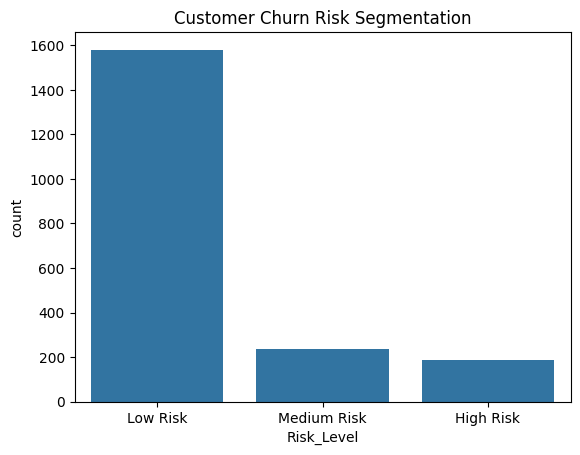

In [36]:
sns.countplot(x="Risk_Level",data=risk_df)
plt.title("Customer Churn Risk Segmentation")
plt.show()

In [43]:
risk_df[risk_df["Risk_Level"]=="High Risk"].head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn_Probability,Risk_Level
7068,699,Germany,Female,54,3,111009.32,1,1,1,155905.79,0.680493,High Risk
2350,617,Germany,Female,58,3,119024.75,2,1,0,35199.24,0.858490,High Risk
4799,551,France,Male,52,1,0.00,1,0,0,63584.55,0.811892,High Risk
9982,655,Germany,Female,46,7,137145.12,1,1,0,115146.40,0.778249,High Risk
5386,642,France,Male,48,9,118317.27,4,0,0,78702.98,0.918289,High Risk


# **Customer Churn Prediction- Project Summary**
**Objective:**

The objective of this project is to build a machine learning model that predicts whether a customer will churn based on historical banking data such as demographics, account details, and usage behavior.

**Methodology:**
* Loaded and inspected the dataset containing 10,000 customers.
* Performed exploratory data analysis to understand churn patterns.
* Removed irrelevant columns such as RowNumber, CustomerId, and Surname.

**Applied preprocessing:**
* Standard scaling for numerical features
* One-hot encoding for categorical features
* Split the dataset into training and testing sets.

**Trained three machine learning models:**
* Logistic Regression
* Random Forest
* Gradient Boosting

**Evaluated models using:**

* Accuracy
* Precision
* Recall
* F1-score
* ROC-AUC

**Key Insights:**
* Customers from Germany show significantly higher churn rates.
* Female customers churn slightly more frequently than male customers.
* Features such as Age, Balance, Tenure, and Number of Products strongly influence churn likelihood.

**Gradient Boosting achieved the best performance with:**
* Accuracy: 0.87
* ROC-AUC: 0.87

**Business Recommendations:**

Banks can reduce churn by:
* Monitoring customers with high balances but low engagement
* Providing loyalty incentives for customers with low tenure
* Identifying high-risk segments using the model and targeting them with retention campaigns
* Using churn probability scores to trigger proactive customer support.